In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool

import numpy as np


In [2]:
from pathlib import Path
import pickle

try:
    START_DIR = Path(__file__).resolve().parent
except NameError:
    START_DIR = Path.cwd().resolve()

DATA_FILE = Path("data") / "RML2016.10a_dict.pkl"
for candidate in (START_DIR, *START_DIR.parents):
    if (candidate / DATA_FILE).exists():
        BASE_DIR = candidate
        break
else:
    raise FileNotFoundError(f"Dataset not found under {START_DIR} or its parents")

DATA_PATH = BASE_DIR / DATA_FILE

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print("✅ Loaded successfully")
print("Total keys:", len(data))

Base dir: D:\amr-explainable
Data path: D:\amr-explainable\data\RML2016.10a_dict.pkl
✅ Loaded successfully
Total keys: 220


In [3]:
import numpy as np 
X = []
y = []
snr = []

for (mod, snr_val), signals in data.items():
    X.append(signals)  # append full batch (1000 samples)
    
    # create labels for this batch
    y.extend([mod] * signals.shape[0])
    snr.extend([snr_val] * signals.shape[0])

# Convert efficiently
X = np.vstack(X)   # fast stacking
y = np.array(y)
snr = np.array(snr)

print("✅ Conversion done")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr shape:", snr.shape)

print("Modulations:", sorted(set(y)))

print("SNR range:", sorted(set(snr)))

print("One sample shape:", X[0].shape)
print("One label:", y[0])
print("One SNR:", snr[0])

✅ Conversion done
X shape: (220000, 2, 128)
y shape: (220000,)
snr shape: (220000,)
Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR range: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
One sample shape: (2, 128)
One label: QPSK
One SNR: 2


In [4]:
import numpy as np

# Avoid division by zero
max_vals = np.max(np.abs(X), axis=(1,2), keepdims=True)
max_vals[max_vals == 0] = 1

X_norm = X / max_vals

print("✅ Normalization done")
print("Range:", X_norm.min(), "to", X_norm.max())

✅ Normalization done
Range: -1.0 to 1.0


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("✅ Encoding done")
print("Classes:", le.classes_)
print("Total classes:", len(le.classes_))

✅ Encoding done
Classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']
Total classes: 11


In [6]:
from sklearn.model_selection import train_test_split
import numpy as np

# stratify by label + snr (important)
strata = np.array([f"{l}_{s}" for l, s in zip(y_encoded, snr)])

# Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X_norm, y_encoded, snr,
    test_size=0.3,
    random_state=42,
    stratify=strata
)

# Val (15%) + Test (15%)
strata_temp = np.array([f"{l}_{s}" for l, s in zip(y_temp, snr_temp)])

X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp,
    test_size=0.5,
    random_state=42,
    stratify=strata_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (154000, 2, 128)
Val: (33000, 2, 128)
Test: (33000, 2, 128)


In [7]:
X_train_full = X_train.copy()
y_train_full = y_train.copy()

X_val_full = X_val.copy()
y_val_full = y_val.copy()

In [8]:
import torch

X_train_full = torch.tensor(X_train_full, dtype=torch.float32)
y_train_full = torch.tensor(y_train_full, dtype=torch.long)

X_val_full = torch.tensor(X_val_full, dtype=torch.float32)
y_val_full = torch.tensor(y_val_full, dtype=torch.long)

In [9]:
print(type(X_train_full))
print(type(y_train_full))
print(X_train_full.shape)
print(y_train_full.shape)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([154000, 2, 128])
torch.Size([154000])


In [10]:
from torch.utils.data import DataLoader, TensorDataset

train_loader_full = DataLoader(
    TensorDataset(X_train_full, y_train_full),
    batch_size=128,
    shuffle=True,
    pin_memory=True
)

val_loader_full = DataLoader(
    TensorDataset(X_val_full, y_val_full),
    batch_size=128
)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [12]:
def build_edge_index(n):
    edges = []
    for i in range(n-1):
        edges.append([i, i+1])
        edges.append([i+1, i])
    return torch.tensor(edges).t().contiguous()

def batch_edge_index(edge_index, B, N):
    return torch.cat([edge_index + i*N for i in range(B)], dim=1)

edge_index = build_edge_index(128).to(device)

In [13]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data

# ---------------- CNN ----------------
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(2, 64, 3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 128, 5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 128, 7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Dropout(0.4)
        )

    def forward(self, x):
        return self.net(x)


# ---------------- GNN ----------------
class GNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = GCNConv(385, 128) 
        self.conv2 = GCNConv(128, 64)
        self.conv3 = GCNConv(64, 64)

        self.fc = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, data, batch):
        x, edge_index = data.x, data.edge_index

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch)

        return self.fc(x)


# ---------------- FULL MODEL ----------------
class CNN_GRU_GNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = CNNFeatureExtractor()

        # 🔥 NEW: GRU (temporal modeling)
        self.gru = nn.GRU(
            input_size=128,
            hidden_size=192,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.gnn = GNNModel(num_classes)

    def forward(self, x, edge_index):

        # CNN
        features = self.cnn(x)  # (B, 128, 128)

        # 🔥 GRU expects (B, N, C)
        x = features.permute(0, 2, 1)

        x, _ = self.gru(x)  

        B, N, C = x.shape

        # reshape for GNN
        x = x.reshape(B * N, C)

        # positional encoding
        pos = torch.arange(N).float().to(x.device) / N
        pos = pos.unsqueeze(0).repeat(B, 1).reshape(-1, 1)

        x = torch.cat([x, pos], dim=1)

        # batch graph
        edge = batch_edge_index(edge_index, B, N)

        data = Data(x=x, edge_index=edge)

        batch = torch.arange(B).repeat_interleave(N).to(x.device)

        return self.gnn(data, batch)

In [14]:
model = CNN_GRU_GNN(num_classes=len(le.classes_)).to(device)

In [37]:
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)

print("Loaded model for fine-tuning")

Loaded model for fine-tuning


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27000\3097411879.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


In [38]:
optimizer = torch.optim.Adam(model.parameters(), lr=7e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [39]:
epochs = 8
best_val_acc = 0

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda") if use_amp else None

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for Xb, yb in train_loader_full:

        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()

        if use_amp:
            with torch.amp.autocast("cuda"):
                out = model(Xb, edge_index)
                loss = criterion(out, yb)
        else:
            out = model(Xb, edge_index)
            loss = criterion(out, yb)

        if use_amp:
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        train_loss += loss.item() * Xb.size(0)

        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss /= total
    train_acc = correct / total

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for Xb, yb in val_loader_full:

            Xb = Xb.to(device)
            yb = yb.to(device)

            if use_amp:
                with torch.amp.autocast("cuda"):
                    out = model(Xb, edge_index)
                    loss = criterion(out, yb)
            else:
                out = model(Xb, edge_index)
                loss = criterion(out, yb)

            val_loss += loss.item() * Xb.size(0)

            preds = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_loss /= total
    val_acc = correct / total

    print(
        f"[FT Epoch {epoch+1}] "
        f"Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f}"
    )

    # ===== SAVE BEST =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "final_finetuned_model.pth")
        print("✅ Saved fine-tuned model")

[FT Epoch 1] Train Acc 0.5955 | Val Acc 0.6085
✅ Saved fine-tuned model
[FT Epoch 2] Train Acc 0.6089 | Val Acc 0.6172
✅ Saved fine-tuned model
[FT Epoch 3] Train Acc 0.6138 | Val Acc 0.6178
✅ Saved fine-tuned model
[FT Epoch 4] Train Acc 0.6161 | Val Acc 0.6221
✅ Saved fine-tuned model
[FT Epoch 5] Train Acc 0.6188 | Val Acc 0.6191
[FT Epoch 6] Train Acc 0.6218 | Val Acc 0.6219
[FT Epoch 7] Train Acc 0.6234 | Val Acc 0.6220
[FT Epoch 8] Train Acc 0.6247 | Val Acc 0.6228
✅ Saved fine-tuned model


In [ ]:
model.load_state_dict(torch.load("final_finetuned_model.pth"))
model.eval()

print("✅ Final model ready")

In [15]:
# For fine tuned model - full dataset with values of SNR < 0
import numpy as np
import torch
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("final_finetuned_model.pth"))
model.eval()

snr_values = sorted(set(snr_test))
snr_acc = []

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

with torch.no_grad():
    for snr_val in snr_values:

        mask = snr_test == snr_val

        if np.sum(mask) == 0:
            continue

        X_snr = X_test_t[mask]
        y_snr = y_test_t[mask]

        correct = 0
        total = 0

        for i in range(0, len(X_snr), 128):
            Xb = X_snr[i:i+128]
            yb = y_snr[i:i+128]

            out = model(Xb, edge_index)
            preds = out.argmax(1)

            correct += (preds == yb).sum().item()
            total += yb.size(0)

        acc = correct / total
        snr_acc.append(acc)

        print(f"SNR {snr_val}: {acc:.4f}")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7840\1221834410.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("final_finetuned_model.pth")

SNR -20: 0.0897
SNR -18: 0.0921
SNR -16: 0.1018
SNR -14: 0.1170
SNR -12: 0.1533
SNR -10: 0.2370
SNR -8: 0.3667
SNR -6: 0.5255
SNR -4: 0.6897
SNR -2: 0.8273
SNR 0: 0.8964
SNR 2: 0.9224
SNR 4: 0.9188
SNR 6: 0.9297
SNR 8: 0.9321
SNR 10: 0.9345
SNR 12: 0.9376
SNR 14: 0.9218
SNR 16: 0.9358
SNR 18: 0.9394


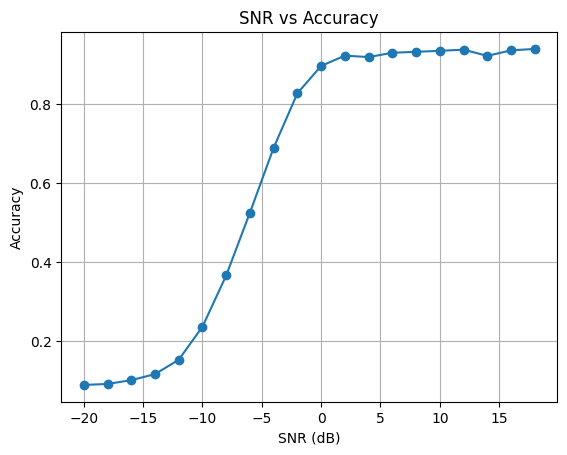

In [16]:
plt.figure()
plt.plot(snr_values, snr_acc, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("SNR vs Accuracy")
plt.grid()
plt.show()

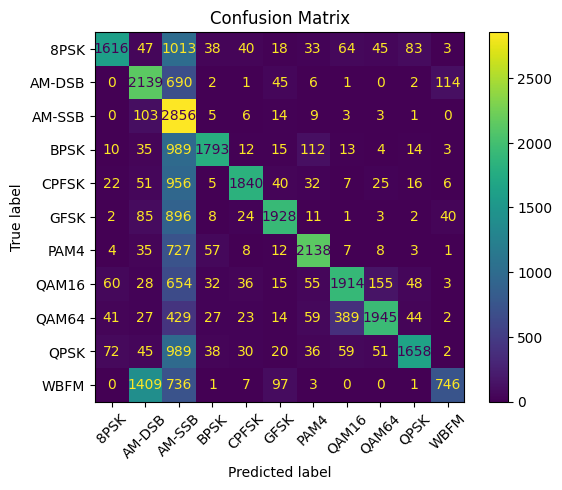

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(0, len(X_test_t), 128):
        Xb = X_test_t[i:i+128]
        yb = y_test_t[i:i+128]

        out = model(Xb, edge_index)
        preds = out.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [19]:
def test_sample(model, X_data, y_data, snr_data, idx, le, device, edge_index):

    model.eval()

    # -------- GET SAMPLE --------
    signal = X_data[idx]
    true_label = y_data[idx]
    true_snr = snr_data[idx]

    # -------- MODEL PREDICTION --------
    signal_t = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(signal_t, edge_index)
        pred = out.argmax(1).item()

    # -------- DECODE LABELS --------
    true_mod = le.inverse_transform([true_label])[0]
    pred_mod = le.inverse_transform([pred])[0]

    # -------- PRINT RESULT --------
    print(f"📡 Sample Index: {idx}")
    print(f"True Modulation : {true_mod}")
    print(f"True SNR        : {true_snr}")
    print(f"Predicted Mod   : {pred_mod}")

    # -------- RETURN (optional) --------
    return true_mod, true_snr, pred_mod

In [20]:
test_sample(
    model,
    X_test,
    y_test,
    snr_test,
    idx=10,
    le=le,
    device=device,
    edge_index=edge_index
)

📡 Sample Index: 10
True Modulation : BPSK
True SNR        : 14
Predicted Mod   : BPSK


('BPSK', 14, 'BPSK')